<center>
<a href="https://www.vision.rwth-aachen.de/">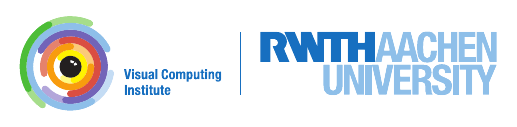</a>
</center>

# Computer Vision Exercises

**Assistants:**
<br>
George Lydakis &lt;lydakis@vision.rwth-aachen.de&gt;
<br>
Lucas Nunes &lt;nunes@vision.rwth-aachen.de&gt;

The assignments are **not mandatory and do not give bonus points for the exam**! The contents are relevant for the exam, though.

Make sure you fill in any place in *code cells* that says:
```python
# YOUR CODE HERE
raise NotImplementedError()
```

Make sure you fill in any place in *text cells* that says:
<br>

`YOUR ANSWER HERE`


### Submission:

⏰ Due date: 2026-05-18 23:59:00

**Important**:
Follow the instructions below when submitting your attempt.\
Submissions not following these instructions will not be graded.

1. Add the names and matriculation numbers of all team members below. Only **one team member should upload** the solutions.
2. **Use jupyter**. Other notebook-editing software (e.g. VSCode, pycharm) might corrupt the notebook files and could have issues with displaying matplotlib interactively.
3. **Do not remove, modify or duplicate** any given cells, except those in which you need to fill in your implementation. You can add new cells in order to present additional texts or plots.
4. **Restart the kernel and re-run the whole notebook** once before submission. After this step, the cell id should be incremental from top to bottom, and all plots should be displayed.
5. **Submit only the `.ipynb` files**, do not upload archives (zip, rar, tar, etc.), images or datasets.
6. **Do not change the filenames** of the `.ipynb` files.

Team members (names and matriculation numbers):
* 
* 
* 
* 

# Graph Cut Segmentation

In this part you will implement foreground-background segmentation using *Markov random fields* (MRF) and graph cuts.

### Recap from the lecture
A Markov random field is a graphical model that expresses the structure of (input and output) variables. In our image segmentation case this structure means that we do not simply model the foreground and background pixel colors but also take into account the neighborhood relations of the pixels. This encodes the intuition that neighboring pixels are more likely to belong to the same region than just two random pixels of the image.

The color (or more generally, appearance) models and the neighborhood relations are combined in a so-called *energy function* (or cost function), which is then minimized to obtain an optimal label-assignment.

Given a structured input (here: image pixel colors) $\mathcal{Y} = \{Y_j|j \in I\}$ we want to find the output (here: labeling) $\mathcal{X} = \{X_j | j \in I\}$ such that

$$
\hat{\mathcal{X}} = \arg \min_{\mathcal{X}} E(\mathcal{X}, \mathcal{Y})
$$

$$
E(\mathcal{X}, \mathcal{Y}) = \sum_{j\in I}{\psi_u (X_j,Y_j)} + \sum_{i, j\in I}{\psi_p (X_i,X_j,Y_i,Y_j)}.
$$

The set $I$ contains all possible pixel indices. In our two-label (binary) segmentation case, the label variables must be either 0 (background) or 1 (foreground) $X_j \in \{0, 1\}$.

The so-called *unary potential* $\psi_u (X_j,Y_j)$ is the cost of assigning the label $X_j$ to a pixel with color $Y_j$. In probabilistic terms, the unary potential is

$$
\psi_u (X_j,Y_j)=-\omega_u \cdot \log p(X_j|Y_j),
$$

with an appropriate model $p$ for the foreground and the background and a weighting factor $\omega_u$. The unaries encourage labeling each pixel with the label (foreground/background) whose color model is a better fit for that particular pixel.

The *pairwise potential* $\psi_p$ incorporates the dependencies between pixels. To speed up the computation, the pairwise model is usually restricted to neighboring pixels and is therefore set to zero if the $i$th and $j$th pixels are not direct neighbors in a 4-neighborhood. In our case it written as:

$$
\psi_p (X_i,X_j,Y_i,Y_j)=\omega_p\cdot
\begin{cases}
1,&\text{if }   X_i\neq X_j \text{ and } i,j \text{ are neighbors}  \\
0,&\text{otherwise}
\end{cases}
$$

with some weighting factor $\omega_p$. Such a pairwise potential encourages neighboring pixels to have the same label because it gives some nonzero cost to each pair of neighboring pixels that are assigned different labels.

After this, a Graph Cut method is used to find the optimal solution $\hat{\mathcal X}$ of the energy function.

### Bird's eye overview

It's easy to get lost in all the details, so here's an roadmap of what we're going to do:

1. Set up the Markov Random Field (define unaries and pairwise potentials), in more detail:
    1. Manually define some approximate initial background and foreground regions in the image
    2. Model the distribution of background and foreground colors based on the colors found in the approximate initial regions
    3. For each pixel independently, calculate the posterior probability of being foreground, based on the models from the previous step (create a "probability map")
    4. Calculate the unary potentials based on the foreground probability map
    5. Define the pairwise potentials (using the neighborhood relations)
2. Use the graph cut algorithm to minimize the energy function of the Markov Random Field and obtain a labeling

### Additional setup

You will not have to implement the graph cut algorithm yourself, we use the `gco-wrapper` package instead. There is no `conda`-package available, but we can install it using `python3 -m pip install gco-wrapper`. (This is a Python wrapper over the C++ gco library. The C++ library can be found at https://vision.cs.uwaterloo.ca/code/). Make sure to activate the environment before running the installation command.

In [1]:
# Some imports and helper functions
import cv2
import gco
import imageio
import matplotlib.pyplot as plt
import numpy as np


def draw_mask_on_image(image, mask, color=(0, 255, 255)):
    """Return a visualization of a mask overlaid on an image."""
    result = image.copy()
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    dilated = cv2.morphologyEx(mask.astype(np.uint8), cv2.MORPH_DILATE, kernel)
    outline = dilated > mask
    result[mask == 1] = (result[mask == 1] * 0.4 + np.array(color) * 0.6).astype(
        np.uint8
    )
    result[outline] = color
    return result

## Mask Initialization

First, manually create initial boxes of foreground and background regions.

We will use these to build color models which model the probability of a pixel color occuring, given either that it is a foreground or a background pixel.

C:\Users\zhens\AppData\Local\Temp\ipykernel_11856\617778111.py:3: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  im = imageio.imread("lotus320.jpg")


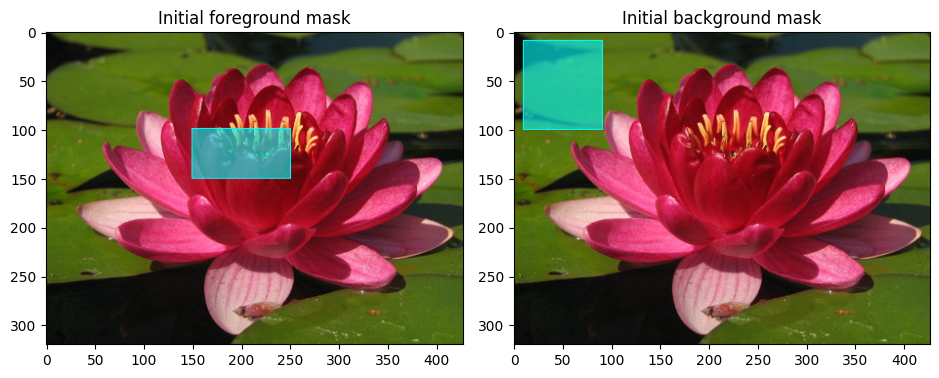

In [2]:
# POINTS: 1

im = imageio.imread("lotus320.jpg")
h, w = im.shape[:2]

# Set up initial foreground and background
# regions for building the color model
init_fg_mask = np.zeros([h, w])
init_bg_mask = np.zeros([h, w])

# Now set some rectangular region of the initial foreground mask to 1.
# This should be a part of the image that is fully foreground.
# The indices in the following line are just an example,
# and they need to be corrected so that only flower pixels are included
init_fg_mask[100:150, 150:250] = 1

# Same for the background (replace the indices)
init_bg_mask[10:100, 10:90] = 1

fig, axes = plt.subplots(1, 2, figsize=(9.5, 5))
axes[0].set_title("Initial foreground mask")
axes[0].imshow(draw_mask_on_image(im, init_fg_mask))
axes[1].set_title("Initial background mask")
axes[1].imshow(draw_mask_on_image(im, init_bg_mask))
fig.tight_layout()

Are bigger or smaller boxes better for color modelling of foreground and background? Why?

A bigger box is better, as more of the background and foreground features are captured.

## Color Modeling by Histograms

A common way to model color distributions is to use *Gaussian mixture models*. However, to keep this exercise simple, we will only use color histograms (i.e. the relative frequencies of quantized colors) in the respective region of the image defined by the boxes. In other words, we model the color simply as a discretized, categorical random variable.

Implement the function `calculate_histogram`. It should take as input the image `im` with values in the range $[0, 255]$ and a `mask` the same size as the image. The mask is 1 at the positions of the image where the histogram should be computed, zero elsewhere. The final parameter `n_bins` defines how many bins should be used in the histogram along each dimension. The function should **return a 3-dimensional array** of shape `[n_bins, n_bins, n_bins]`, containing the relative frequency for each `(r, g, b)` color bin within the region of the image defined by the mask, i.e. the fraction of pixels falling within each bin. The histogram should be normalized (sum to 1). All bins are initialized with a small value ($10^{−3}$) to avoid relative frequencies which are zero. (Why would zeros be a problem?)

In [7]:
# POINTS: 3

def calculate_histogram(im, mask, n_bins):
    histogram = np.full((n_bins, n_bins, n_bins), fill_value=0.001)

    masked_pixels = im[mask == 1]

    counts, _ = np.histogramdd(masked_pixels, bins=n_bins, range=[(0, 256), (0, 256), (0, 256)])

    histogram += counts

    histogram /= np.sum(histogram)
            
    return histogram

The following plot displays the marginal distributions of the regions you defined above.

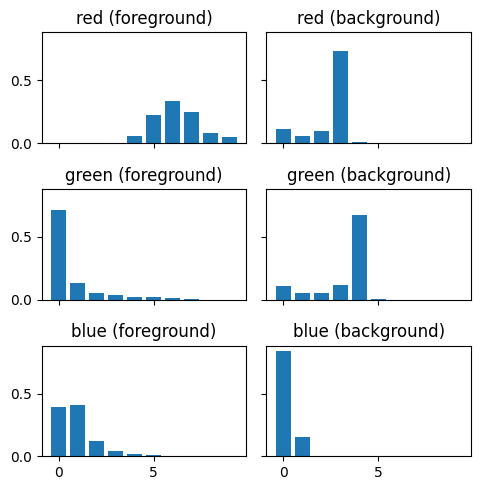

In [8]:
n_bins = 10
fg_histogram = calculate_histogram(im, init_fg_mask, n_bins)
bg_histogram = calculate_histogram(im, init_bg_mask, n_bins)

fig, axes = plt.subplots(
    3,
    2,
    figsize=(5, 5),
    sharex=True,
    sharey=True,
    num="Relative frequency of color bins",
)

x = np.arange(n_bins)
axes[0, 0].bar(x, np.sum(fg_histogram, (1, 2)))
axes[0, 0].set_title("red (foreground)")
axes[1, 0].bar(x, np.sum(fg_histogram, (0, 2)))
axes[1, 0].set_title("green (foreground)")
axes[2, 0].bar(x, np.sum(fg_histogram, (0, 1)))
axes[2, 0].set_title("blue (foreground)")

axes[0, 1].bar(x, np.sum(bg_histogram, (1, 2)))
axes[0, 1].set_title("red (background)")
axes[1, 1].bar(x, np.sum(bg_histogram, (0, 2)))
axes[1, 1].set_title("green (background)")
axes[2, 1].bar(x, np.sum(bg_histogram, (0, 1)))
axes[2, 1].set_title("blue (background)")
fig.tight_layout()

How does the histogram calculation in `calculate_histogram` differ from creating 3 separate histograms, for R, G, and B individually? Would this alternative method (separate histograms) yield more or or less information about the image?

Zeroes would be a problem because the values are usually used to calculate probabilities, and the probability might be multiplied to 0.
Separate histograms would yield less information, as we lose the correspondence of the different colour channels to each other for each pixel.

## Foreground Probability Map

The next step in the segmentation process is to estimate a probability map: For each pixel we want to estimate the probability that it belongs to the foreground. This will be used as basis for the unary potential.

The function `foreground_pmap(im, fg_histogram, bg_histogram)` should take the image `im` and the two histograms `fg_histogram`, `bg_histogram` estimated from the foreground region and the background region respecively. It should return an array of shape $\texttt{height}\times\texttt{width}$ containing the probability of each pixel belonging to the foreground. To estimate the required probability $p(c|[r, g, b])$ from the computed histograms, a class prior $p(c)$ of $0.5$ should be used, which means that both foreground and background pixels are equally likely a priori. 

Recall Bayes' theorem applied to this case:

$$
p(c\ |\ r,g,b) = \frac{p(c) \cdot p(r,g,b\ |\ c)}{p(r,g,b)} = \frac{p(c)\cdot p(r,g,b\ |\ c)}{\sum_{\tilde{c}} p(\tilde{c}) \cdot p(r,g,b\ |\ \tilde{c}) }
$$

In [11]:
# POINTS: 4

def foreground_pmap(im, fg_histogram, bg_histogram):
    n_bins = fg_histogram.shape[0]

    bin_r = np.clip((im[:, :, 0] / 256 * n_bins).astype(int), 0, n_bins - 1)
    bin_g = np.clip((im[:, :, 1] / 256 * n_bins).astype(int), 0, n_bins - 1)
    bin_b = np.clip((im[:, :, 2] / 256 * n_bins).astype(int), 0, n_bins - 1)

    p_rgb_given_fg = fg_histogram[bin_r, bin_g, bin_b]
    p_rgb_given_bg = bg_histogram[bin_r, bin_g, bin_b]

    result = p_rgb_given_fg / (p_rgb_given_fg + p_rgb_given_bg)

    return result

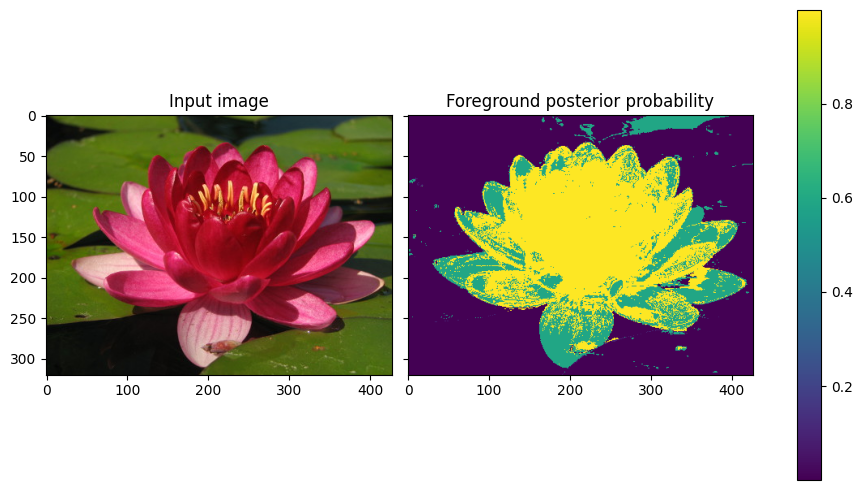

In [12]:
foreground_prob = foreground_pmap(im, fg_histogram, bg_histogram)
fig, axes = plt.subplots(1, 2, figsize=(9.5, 5), sharey=True)
axes[0].imshow(im)
axes[0].set_title("Input image")
im_plot = axes[1].imshow(foreground_prob, cmap="viridis")
axes[1].set_title("Foreground posterior probability")
fig.tight_layout()
fig.colorbar(im_plot, ax=axes)
foreground_map = foreground_prob > 0.5

Explain what you see in the probability map.

The middle of the flower has the highest probability to be foreground, but there are some parts of the background that is incorrectly categorized as the foreground.

## Unary Potentials
Use the previously computed probability map `foreground_map` to compute the unary potential for both foreground and background.

This function `unary_potentials(probability_map, unary_weight)` shall use the `probability_map` and a scalar weighting factor to compute the unary potentials. It should return a matrix of the same size as the probability matrix.

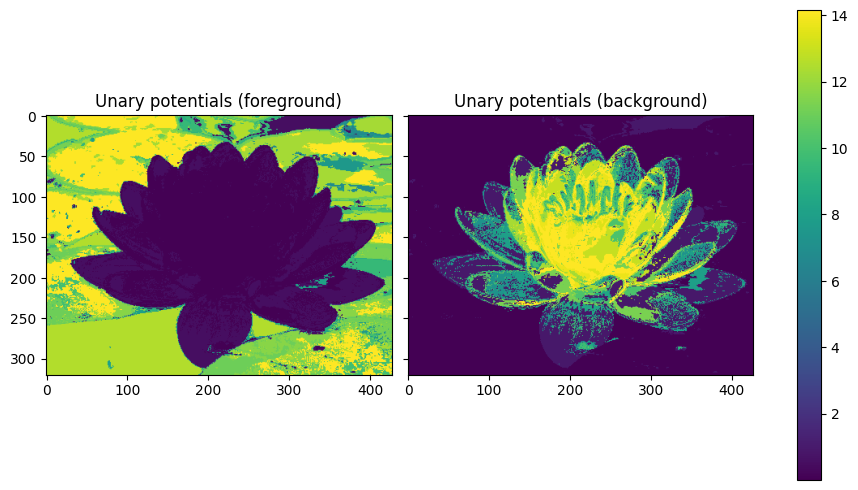

In [14]:
# POINTS: 1

def unary_potentials(probability_map, unary_weight):
    return -np.log(probability_map) * unary_weight


unary_weight = 1
unary_fg = unary_potentials(foreground_prob, unary_weight)
unary_bg = unary_potentials(1 - foreground_prob, unary_weight)
fig, axes = plt.subplots(1, 2, figsize=(9.5, 5), sharey=True)
axes[0].imshow(unary_fg)
axes[0].set_title("Unary potentials (foreground)")
im_plot = axes[1].imshow(unary_bg)
axes[1].set_title("Unary potentials (background)")
fig.tight_layout()
fig.colorbar(im_plot, ax=axes)

Why are the unary potentials for the foreground so small in the middle of the flower?

The energy required to assign the middle flower as foreground is very low.

## Pairwise Potentials

Create a function to compute the prefactor $w_p$ of the pairwise potential for two specific pixels. Implement the function below, where `im` is the image, `(x1, y1), (x2, y2)` are the pixel coordinates in the image and the last parameter is the weight $\omega_p$ for the pairwise potential. (Do not confuse `(x1, y1), (x2, y2)` with the $X_j, Y_j$ in the formulas. There $\mathcal X$ was the label and $\mathcal Y$ the pixel value, here they are the $x$ and $y$ coordinates in the image) 

We want to use the so-called *contrast sensitive Potts model*. The pairwise potential should be:

$$
\psi_p (X_i,X_j,Y_i,Y_j,i,j)=\omega_p\cdot \exp\left(-\omega_d\|Y_i - Y_j\|^2\right)\cdot 
\begin{cases}
1,&\text{if } X_i \neq X_j \text{ and } i,j \text{ are neighbors}  \\
0,&\text{otherwise}
\end{cases}
$$

This means the prefactor is $\omega_p\cdot \exp\left(-\omega_d\|Y_i - Y_j\|^2\right)$. For simplicity, you can hardcode the parameter $\omega_d = 0.1$. 

In [15]:
# POINTS: 3

def pairwise_potential_prefactor(im, x1, y1, x2, y2, pairwise_weight):
    wd = 0.1

    color_i = im[y1, x1]
    color_j = im[y2, x2]

    squared_color_dist = np.sum((color_i -color_j) ** 2)

    return pairwise_weight * np.exp(-wd * squared_color_dist)

There often is some confusion around the fact that we are defining a pairwise potential which is based on the labelling (i.e., $X_i \neq X_j$ in the above equation), without knowing the labels at this point. As you see in the code, we actually do not use the labels at this point. We only define the potential cost in case the graph cut algorithm decides that two neighboring pixels are different classes.

You can compare this to finding the minimum of a polynomial as you learned in school, the value of the polynomial is the cost (e.g. with $f(x)=x^2$ the cost of selecting $x=3$ would be $9$). The algorithm is simple: set the first derivative to $0$ and solve for $x$, then check whether the second derivative is positive (this corresponds to the graph-cut algorithm). You can apply it on any polynomial (you can apply it on any image), there is no need to define a specific $x$ (there is not need to define a specific labeling). The algorithm only needs to know the cost for selecting a certain $x$ (a certain labeling), which is given by the polynomial (which is given by the edge costs). The result is the $x$ (the labeling) with minimal cost.

Using the functions from the previous task, implement a function to compute all the pairwise potentials for the image using 4-neighborhoods. That means only the top, bottom, left and right neighboring pixels should be connected to a given pixel.

The function `pairwise_potentials` should return the `edges` (represented as index pairs) and an array `costs` containing the corresponding edge costs (i.e. the value of the pairwise potential prefactor). You have to use a linearized index instead of (x,y)-coordinates for the edge indices. A conversion function is supplied (`coords_to_index(x, y, width)`).

Thus, `edges` should be an integer array of shape $k\times 2$, while `costs` should have length $k$, where $k$ is the number of neighborhood-edges in the image grid.

In [30]:
# POINTS: 4

def coords_to_index(x, y, width):
    return y * width + x


def pairwise_potentials(im, pairwise_weight):
    im = im.astype(np.float32) / 255

    height, width, _ = im.shape

    edges = []
    costs = []

    for y in range(height):
        for x in range(width):
            # Get the linearized coordinates
            idx_i = coords_to_index(x, y, width)
            color_i = im[y, x]

            # Check the pixel to the right
            if x + 1 < width:
                idx_j = coords_to_index(x + 1, y, width)
                color_j = im[y, x + 1]
                
                edges.append([idx_i, idx_j])
                costs.append(pairwise_potential_prefactor(im, x, y, x + 1, y, pairwise_weight))
                
            # 3. Check the BOTTOM neighbor (if not on the bottom edge)
            if y + 1 < height:
                idx_j = coords_to_index(x, y + 1, width)
                color_j = im[y + 1, x]
                
                edges.append([idx_i, idx_j])
                costs.append(pairwise_potential_prefactor(im, x, y, x, y + 1, pairwise_weight))
    
    return np.array(edges), np.array(costs)


pairwise_edges, pairwise_costs = pairwise_potentials(im, pairwise_weight=10)

Now you can execute the optimization procedure and plot the resulting labeling.

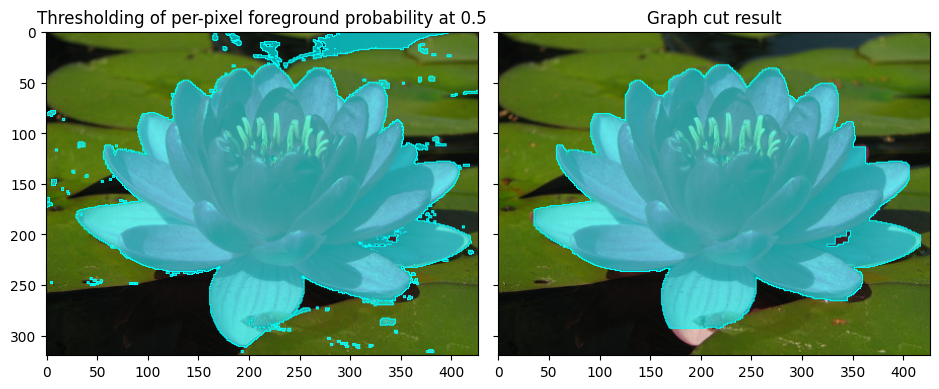

In [31]:
def graph_cut(unary_fg, unary_bg, pairwise_edges, pairwise_costs):
    unaries = np.stack([unary_bg.flat, unary_fg.flat], axis=-1)
    labels = gco.cut_general_graph(
        pairwise_edges,
        pairwise_costs,
        unaries,
        1 - np.eye(2),
        n_iter=-1,
        algorithm="swap",
    )
    return labels.reshape(unary_fg.shape)


graph_cut_result = graph_cut(unary_fg, unary_bg, pairwise_edges, pairwise_costs)
fig, axes = plt.subplots(1, 2, figsize=(9.5, 5), sharey=True)
axes[0].set_title("Thresholding of per-pixel foreground probability at 0.5")
axes[0].imshow(draw_mask_on_image(im, foreground_prob > 0.5))
axes[1].set_title("Graph cut result")
axes[1].imshow(draw_mask_on_image(im, graph_cut_result))
fig.tight_layout()

Explain what you see. Why is the segmentation the way it is? What happens if you increase the pairwise weight in the previous cell?

With higher pairwise weights, the penalty for graph cutting is higher, and thus it decreases the amount of cuts performed.

## Try further images

First, create a single function that runs the whole segmentation pipeline starting from the image and the initial regions.

`segment_image(...)` should return the final binary segmentation mask with 1 at the foreground pixels and 0 at the background.

In [37]:
# POINTS: 2

def segment_image(
    im, init_fg_mask, init_bg_mask, unary_weight, pairwise_weight, n_bins
):
    fg_histogram = calculate_histogram(im, init_fg_mask, n_bins)
    bg_histogram = calculate_histogram(im, init_bg_mask, n_bins)

    fg_pmap = foreground_pmap(im, fg_histogram, bg_histogram)
    bg_pmap = 1.0 - fg_pmap

    unary_potentials_fg = unary_potentials(fg_pmap, unary_weight)
    unary_potentials_bg = unary_potentials(bg_pmap, unary_weight)

    edges, costs = pairwise_potentials(im, pairwise_weight)

    return graph_cut(unary_potentials_fg, unary_potentials_bg, edges, costs)

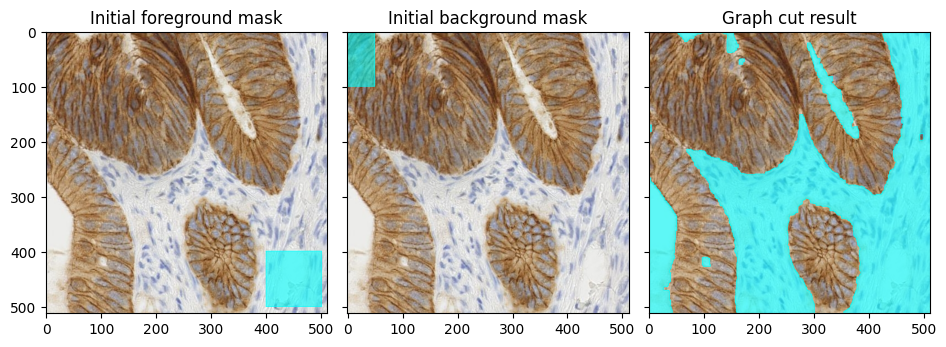

In [43]:
# POINTS: 1

import skimage.data

im_cells = skimage.data.immunohistochemistry()
h_cells, w_cells = im_cells.shape[:2]
fg_mask_cells = np.zeros([h_cells, w_cells])
bg_mask_cells = np.zeros([h_cells, w_cells])

# Set some appropriate parts of fg_mask and bg_mask to 1 for initialization.
fg_mask_cells[400:500, 400:500] = 1
bg_mask_cells[0:100, 0:50] = 1

graph_cut_result_cells = segment_image(
    im_cells, fg_mask_cells, bg_mask_cells, unary_weight=1, pairwise_weight=15, n_bins=8
)

fig, axes = plt.subplots(1, 3, figsize=(9.5, 5), sharey=True)
axes[0].set_title("Initial foreground mask")
axes[0].imshow(draw_mask_on_image(im_cells, fg_mask_cells))
axes[1].set_title("Initial background mask")
axes[1].imshow(draw_mask_on_image(im_cells, bg_mask_cells))
axes[2].set_title("Graph cut result")
axes[2].imshow(draw_mask_on_image(im_cells, graph_cut_result_cells))
fig.tight_layout()

Does it look good? Which parameter would you need to change to reduce the number of holes in the segmentation? Try it.

Now try segmenting `im = skimage.data.stereo_motorcycle()[0]` using this technique.

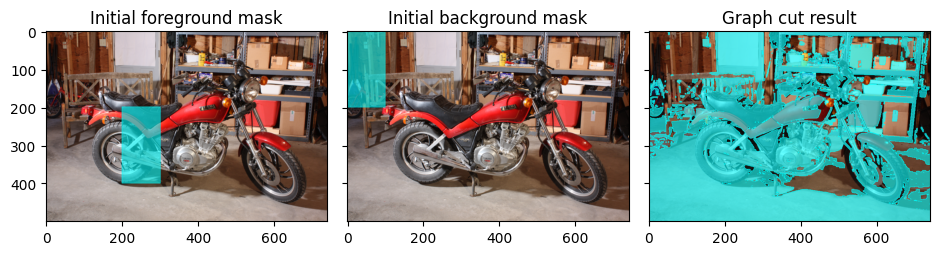

In [46]:
# POINTS: 1

import skimage.data

im_bike = skimage.data.stereo_motorcycle()[0]
h_bike, w_bike = im_bike.shape[:2]
fg_mask_bike = np.zeros([h_bike, w_bike])
bg_mask_bike = np.zeros([h_bike, w_bike])

# Set some appropriate parts of fg_mask and bg_mask to 1 for initialization.
fg_mask_bike[200:400, 200:300] = 1
bg_mask_bike[0:200, 0:100] = 1

graph_cut_result_bike = segment_image(
    im_bike, fg_mask_bike, bg_mask_bike, unary_weight=1, pairwise_weight=1, n_bins=8
)

fig, axes = plt.subplots(1, 3, figsize=(9.5, 5), sharey=True)
axes[0].set_title("Initial foreground mask")
axes[0].imshow(draw_mask_on_image(im_bike, fg_mask_bike))
axes[1].set_title("Initial background mask")
axes[1].imshow(draw_mask_on_image(im_bike, bg_mask_bike))
axes[2].set_title("Graph cut result")
axes[2].imshow(draw_mask_on_image(im_bike, graph_cut_result_bike))
fig.tight_layout()

Can you segment the motorbike by fiddling with the parameters? Why or why not?

It's not easy to segment the motorbike properly, because the background and foreground has pretty complex patterns that are not uniform.

## Iterative Segmentation

We can make the result better if we iterate the labeling process several times. Implement `iterative_opt`, a method to execute the optimization process iteratively. 

Use the previously computed labeling as initial segmentation (instead of the rectangular masks we used above) and estimate new models (histograms and unaries) for foreground and background based on these. Solve the graph cut problem and use the resulting segmentation in the next iteration.

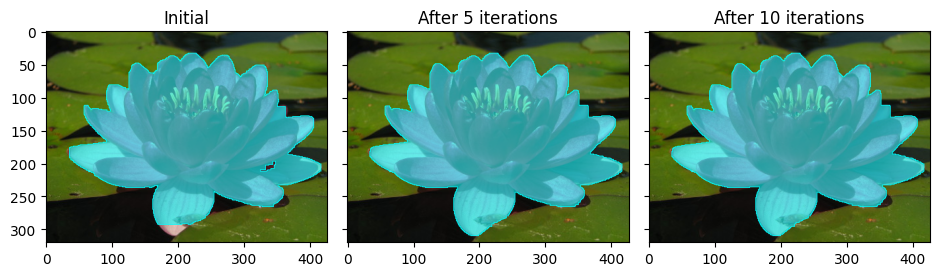

In [47]:
# POINTS: 4

def iterative_opt(
    im, fg_mask, n_bins, unary_weight, pairwise_edges, pairwise_costs, n_iter
):
    cur_fg_mask = fg_mask.copy()
    for i in range(n_iter):
        cur_bg_mask = 1.0 - cur_fg_mask

        fg_histogram = calculate_histogram(im, cur_fg_mask, n_bins)
        bg_histogram = calculate_histogram(im, cur_bg_mask, n_bins)

        fg_pmap = foreground_pmap(im, fg_histogram, bg_histogram)
        bg_pmap = 1.0 - fg_pmap
        
        unary_fg = unary_potentials(fg_pmap, unary_weight)
        unary_bg = unary_potentials(bg_pmap, unary_weight)
        
        cur_fg_mask = graph_cut(unary_fg, unary_bg, pairwise_edges, pairwise_costs)

    return cur_fg_mask


labels_5 = iterative_opt(
    im, graph_cut_result, n_bins, unary_weight, pairwise_edges, pairwise_costs, n_iter=5
)
labels_10 = iterative_opt(
    im, labels_5, n_bins, unary_weight, pairwise_edges, pairwise_costs, n_iter=5
)

fig, axes = plt.subplots(1, 3, figsize=(9.5, 4), sharex=True, sharey=True)
axes[0].set_title("Initial")
axes[0].imshow(draw_mask_on_image(im, graph_cut_result))
axes[1].set_title("After 5 iterations")
axes[1].imshow(draw_mask_on_image(im, labels_5))
axes[2].set_title("After 10 iterations")
axes[2].imshow(draw_mask_on_image(im, labels_10))
fig.tight_layout()